In [5]:
%load_ext autoreload
%autoreload 2

In [6]:
from datasets import concatenate_datasets
from protest_impact.data.protests.detection import load_aglpn_dataset

aglpn = load_aglpn_dataset()
# merge train and dev and test
aglpn = concatenate_datasets([aglpn["train"], aglpn["dev"], aglpn["test"]])

Using custom data configuration protest-e19b294f0b7cdc66
Found cached dataset json (/Users/david/.cache/huggingface/datasets/json/protest-e19b294f0b7cdc66/0.0.0/0f7e3662623656454fcd2b650f34e886a7db4b9104504885bd462096cc7a9f51)


  0%|          | 0/1 [00:00<?, ?it/s]

Loading cached processed dataset at /Users/david/.cache/huggingface/datasets/json/protest-e19b294f0b7cdc66/0.0.0/0f7e3662623656454fcd2b650f34e886a7db4b9104504885bd462096cc7a9f51/cache-7ff70fceeec07c9c.arrow
Loading cached split indices for dataset at /Users/david/.cache/huggingface/datasets/json/protest-e19b294f0b7cdc66/0.0.0/0f7e3662623656454fcd2b650f34e886a7db4b9104504885bd462096cc7a9f51/cache-51a11700ecd7d8d9.arrow and /Users/david/.cache/huggingface/datasets/json/protest-e19b294f0b7cdc66/0.0.0/0f7e3662623656454fcd2b650f34e886a7db4b9104504885bd462096cc7a9f51/cache-42e4d11efd9b0c09.arrow
Loading cached split indices for dataset at /Users/david/.cache/huggingface/datasets/json/protest-e19b294f0b7cdc66/0.0.0/0f7e3662623656454fcd2b650f34e886a7db4b9104504885bd462096cc7a9f51/cache-121723c21a6ce906.arrow and /Users/david/.cache/huggingface/datasets/json/protest-e19b294f0b7cdc66/0.0.0/0f7e3662623656454fcd2b650f34e886a7db4b9104504885bd462096cc7a9f51/cache-d2d1311a2c9105f2.arrow
Loading cache

In [7]:
from collections import Counter

c = Counter(aglpn["label"])
c, c[1] / (c[0] + c[1])

(Counter({1: 120, 0: 680}), 0.15)

In [8]:
homepages = Counter(a["homepage"] for a in aglpn["meta"]).most_common(30)

<AxesSubplot: xlabel='homepage'>

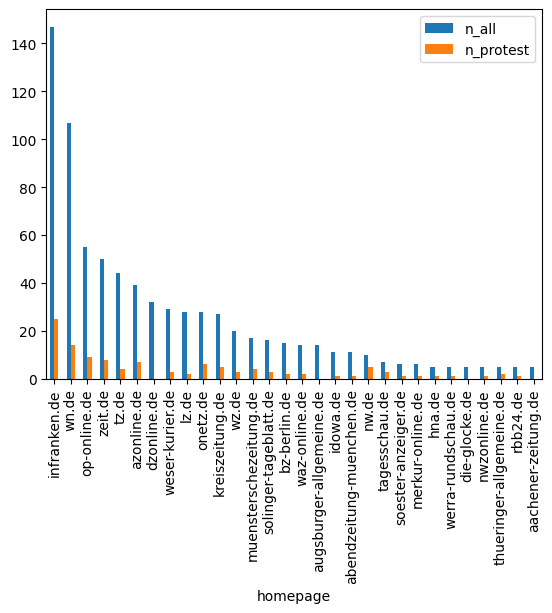

In [9]:
import pandas as pd

n_protest = lambda homepage: len(
    [a for a in aglpn if a["meta"]["homepage"] == homepage and a["label"] == 1]
)
comparison_data = pd.DataFrame(
    [
        {"homepage": homepage, "n_all": n_all, "n_protest": n_protest(homepage)}
        for homepage, n_all in homepages
    ]
)
# bar plot
comparison_data.plot.bar(x="homepage", y=["n_all", "n_protest"])

<AxesSubplot: >

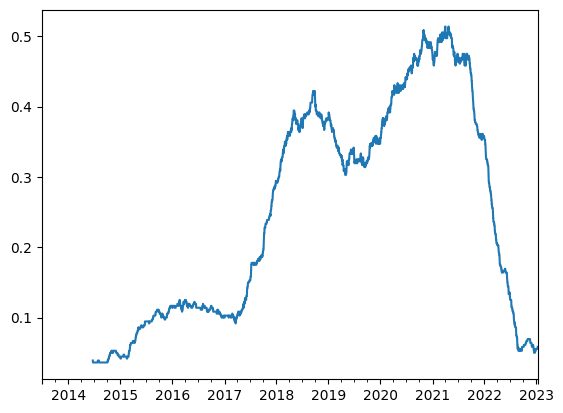

In [46]:
from datetime import date

from dateutil import parser

dates = pd.Series([parser.parse(a["meta"]["date"]).date() for a in aglpn])
# rolling average

# transform to counts per day (including days without protests)
counts = dates.value_counts().sort_index()
counts = counts.reindex(
    pd.date_range(counts.index.min(), counts.index.max()), fill_value=0
)
counts = counts.rolling(360).mean()

# plot
counts.plot()

Just a test change.

In [47]:
import json

from protest_impact.util import project_root

with open(project_root / "data" / "news" / "protest_news_shuffled_v2.jsonl") as f:
    news = [json.loads(line) for line in f]

len(news)

193556